# 4. Non-Stationary Transformer Playground

In this notebook, we execute the refined, modularized version of the **Non-Stationary Transformer** (NeurIPS 2022). 

Following our MLOps standards, the internal PyTorch mathematics (Series Stationarization and De-stationary Attention) are encapsulated in `src/models/transformer_model.py`. This notebook serves as an interactive entry point to trigger the full pipeline: **Preprocessing -> Cluster Training -> Rolling Forecast -> Evaluation**.

### Pipeline Overview:
1. **Device Detection**: Optimized execution on MPS (Mac), CUDA (Nvidia), or CPU.
2. **Cluster Aggregation**: Training one neural model per behavioral shape (Light, Medium, Heavy, etc.) using hourly averages.
3. **Rolling Window Forecast**: Simulating a day-ahead operational scenario.
4. **Safe Merge 2.0**: Resampling cluster forecasts back to 15-minute intervals and un-scaling via individual client scalers.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import pandas as pd

# Add project root to path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.models.transformer_model import run_transformer_pipeline
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

# ---------------------------------------------------------
# Device selection: MPS (Apple Silicon) > CUDA > CPU
# ---------------------------------------------------------
device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available() 
                      else "cpu")

print(f"Project Root: {PROJECT_ROOT}")
print(f"Active Device: {device.type.upper()}")

Project Root: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity
Active Device: MPS


In [2]:
import os
import sys
import pandas as pd

# 1. Setup Project Root to allow importing from 'src'
# Assuming the notebook is inside the 'notebooks' folder
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 2. Import MLOps functions from our new Transformer module
from src.models.transformer_model import (
    preprocess_and_split,
    train_models,
    predict_models,
    evaluate_models,
    save_transformer_artifacts
)

# 3. Import Visualization tools
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

# Define mode and path
MODE = 'day_ahead'
DATA_PATH = os.path.join(PROJECT_ROOT, "Datasets", "processed_electricity_data.parquet")

device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available() 
                      else "cpu")

print(f"Project Root: {PROJECT_ROOT}")
print(f"Active Device: {device.type.upper()}")

# 4. Load the raw parquet data
print("Loading raw dataset...")
df_long = pd.read_parquet(DATA_PATH)
print(f"Data loaded successfully. Shape: {df_long.shape}")

Project Root: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity
Active Device: MPS
Loading raw dataset...
Data loaded successfully. Shape: (41548234, 21)


In [3]:
# 2. Preprocess, scale, and split the data
print(f"Running preprocessing for mode: {MODE}...")
train_agg, test_agg, test_raw, client_scalers, scaler_weather, regressors = preprocess_and_split(
    df_long, 
    mode=MODE
)

print("\n--- Preprocessing Checks ---")
print(f"Train Aggregated Shape: {train_agg.shape}")
print(f"Test Aggregated Shape: {test_agg.shape}")
print(f"Regressors (Features) Count: {len(regressors)}")
print(f"Regressors List: {regressors}")

Running preprocessing for mode: day_ahead...
Preparing train/test split and scaling (Mode: DAY_AHEAD)...


Scaling Clients: 100%|██████████| 369/369 [00:06<00:00, 53.60it/s]


Aggregating data by Cluster for Transformer training...

--- Preprocessing Checks ---
Train Aggregated Shape: (487675, 11)
Test Aggregated Shape: (175205, 11)
Regressors (Features) Count: 9
Regressors List: ['Consumption', 'HDH', 'CDH', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly', 'Is_Weekend', 'Is_Holiday']


In [4]:
# 3. Train the Transformer models per cluster
print("Starting training process...")
cluster_models = train_models(train_agg, regressors)

print(f"\nTraining complete. Models trained: {list(cluster_models.keys())}")

Starting training process...

Training Cluster 0.0
  Epoch 1 | Train: 0.16172 | Val: 0.27169
  Epoch 2 | Train: 0.03926 | Val: 0.27536
  Epoch 3 | Train: 0.03152 | Val: 0.26517
  Epoch 4 | Train: 0.02740 | Val: 0.28092
  Epoch 5 | Train: 0.02467 | Val: 0.27884
  Epoch 6 | Train: 0.02249 | Val: 0.27121

Training Cluster 1.0
  Epoch 1 | Train: 0.15655 | Val: 0.05118
  Epoch 2 | Train: 0.05679 | Val: 0.03677
  Epoch 3 | Train: 0.04486 | Val: 0.03332
  Epoch 4 | Train: 0.03954 | Val: 0.03191
  Epoch 5 | Train: 0.03576 | Val: 0.03065
  Epoch 6 | Train: 0.03320 | Val: 0.02951
  Epoch 7 | Train: 0.03104 | Val: 0.03048
  Epoch 8 | Train: 0.02963 | Val: 0.02909
  Epoch 9 | Train: 0.02816 | Val: 0.02823
  Epoch 10 | Train: 0.02691 | Val: 0.02887

Training Cluster 2.0
  Epoch 1 | Train: 0.10319 | Val: 0.05758
  Epoch 2 | Train: 0.02783 | Val: 0.04385
  Epoch 3 | Train: 0.02170 | Val: 0.04296
  Epoch 4 | Train: 0.01856 | Val: 0.03906
  Epoch 5 | Train: 0.01645 | Val: 0.03390
  Epoch 6 | Train: 0.0

In [5]:
# 4. Generate rolling forecasts and un-scale to individual clients
print("Starting prediction and safe merge...")
test_raw = predict_models(
    cluster_models, 
    train_agg, 
    test_agg, 
    test_raw, 
    client_scalers, 
    regressors
)

# CRITICAL CHECK: Verify that the Safe Merge worked and columns exist
print("\n--- Safe Merge Checks ---")
print("Columns in test_raw after prediction:")
print(list(test_raw.columns))

# Let's peek at a few rows that shouldn't be NaN
valid_preds = test_raw.dropna(subset=['Predicted_kW'])
print(f"\nNumber of valid predictions (non-NaN): {len(valid_preds)}")
if len(valid_preds) > 0:
    display(valid_preds[['ClientID', 'Cluster', 'Date', 'Actual_kW', 'Predicted_kW']].head())
else:
    print("WARNING: All predictions are NaN. The merge failed due to date misalignment.")

Starting prediction and safe merge...
Generating forecasts for Cluster 0...
Generating forecasts for Cluster 1...
Generating forecasts for Cluster 2...
Generating forecasts for Cluster 3...
Generating forecasts for Cluster 4...


Un-scaling Clients: 100%|██████████| 369/369 [00:02<00:00, 182.49it/s]



--- Safe Merge Checks ---
Columns in test_raw after prediction:
['Date', 'Weekday', 'Hour', 'Month', 'Is_Weekend', 'Is_Holiday', 'ClientID', 'Consumption', 'HDH', 'CDH', 'Lag_15min', 'Lag_1h', 'Lag_24h', 'Lag_1week', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly', 'Rolling_Mean_4h', 'Cluster', 'Consumer_Category', 'Consumption_Scaled', 'Predicted_Consumption_Scaled', 'Predicted_kW', 'Actual_kW']

Number of valid predictions (non-NaN): 12262950


,ClientID,Cluster,Date,Actual_kW,Predicted_kW
0,MT_001,1.0,2014-01-01 00:00:00,2.538071,8.997210
1,MT_001,1.0,2014-01-01 00:15:00,2.538071,8.997210
2,MT_001,1.0,2014-01-01 00:30:00,2.538071,8.997210
3,MT_001,1.0,2014-01-01 00:45:00,2.538071,8.997210
4,MT_001,1.0,2014-01-01 01:00:00,2.538071,7.370927


In [6]:
valid_preds

,Date,Weekday,Hour,Month,Is_Weekend,Is_Holiday,ClientID,Consumption,HDH,CDH,...,CDH_lag24h,HDH_anomaly,CDH_anomaly,Rolling_Mean_4h,Cluster,Consumer_Category,Consumption_Scaled,Predicted_Consumption_Scaled,Predicted_kW,Actual_kW
0,2014-01-01 00:00:00,3,1,1,False,True,MT_001,2.538071,0.786603,-0.526592,...,-0.526643,-0.413786,0.00145,2.696701,1.0,Light,-0.500422,0.473734,8.997210,2.538071
1,2014-01-01 00:15:00,3,1,1,False,True,MT_001,2.538071,0.786603,-0.526592,...,-0.526643,-0.413128,0.00145,2.696701,1.0,Light,-0.500422,0.473734,8.997210,2.538071
2,2014-01-01 00:30:00,3,1,1,False,True,MT_001,2.538071,0.786603,-0.526592,...,-0.526643,-0.412470,0.00145,2.696701,1.0,Light,-0.500422,0.473734,8.997210,2.538071
3,2014-01-01 00:45:00,3,1,1,False,True,MT_001,2.538071,0.786603,-0.526592,...,-0.526643,-0.411811,0.00145,2.696701,1.0,Light,-0.500422,0.473734,8.997210,2.538071
4,2014-01-01 01:00:00,3,2,1,False,True,MT_001,2.538071,0.767354,-0.526592,...,-0.526643,-0.442507,0.00145,2.696701,1.0,Light,-0.500422,0.228461,7.370927,2.538071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12853621,2014-12-31 22:00:00,3,23,12,False,False,MT_370,7891.892090,2.132305,-0.526592,...,-0.526643,1.505445,0.00145,8949.324219,3.0,Heavy,-2.207039,0.443204,19185.597656,7891.892090
12853622,2014-12-31 22:15:00,3,23,12,False,False,MT_370,7945.945801,2.132305,-0.526592,...,-0.526643,1.504512,0.00145,8766.891602,3.0,Heavy,-2.194354,0.443204,19185.597656,7945.945801
12853623,2014-12-31 22:30:00,3,23,12,False,False,MT_370,7351.351562,2.132305,-0.526592,...,-0.526643,1.503579,0.00145,8601.351562,3.0,Heavy,-2.333885,0.443204,19185.597656,7351.351562
12853624,2014-12-31 22:45:00,3,23,12,False,False,MT_370,7189.188965,2.132305,-0.526592,...,-0.526643,1.502647,0.00145,8452.703125,3.0,Heavy,-2.371939,0.443204,19185.597656,7189.188965


In [7]:
# 5. Compute portfolio WMAPE and MAPE
print("Evaluating portfolio metrics...")
portfolio_eval, summary = evaluate_models(test_raw)

# Display the summary table
display(summary)

Evaluating portfolio metrics...

Evaluating Portfolio Performance...

--- TRANSFORMER PERFORMANCE BY CLUSTER ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0               32.41             5.26
1.0               51.86             5.44
2.0              155.76            16.23
3.0               17.68            15.20
4.0                7.38             5.07

Global Portfolio MAPE:  53.02%
Global Portfolio WMAPE: 10.14%


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
0.0,32.41,5.26
1.0,51.86,5.44
2.0,155.76,16.23
3.0,17.68,15.20
4.0,7.38,5.07


Saving artifacts to disk...

Transformer artifacts saved to: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/agent/artifacts/nst_cluster_day_ahead.pkl
Generating plots...


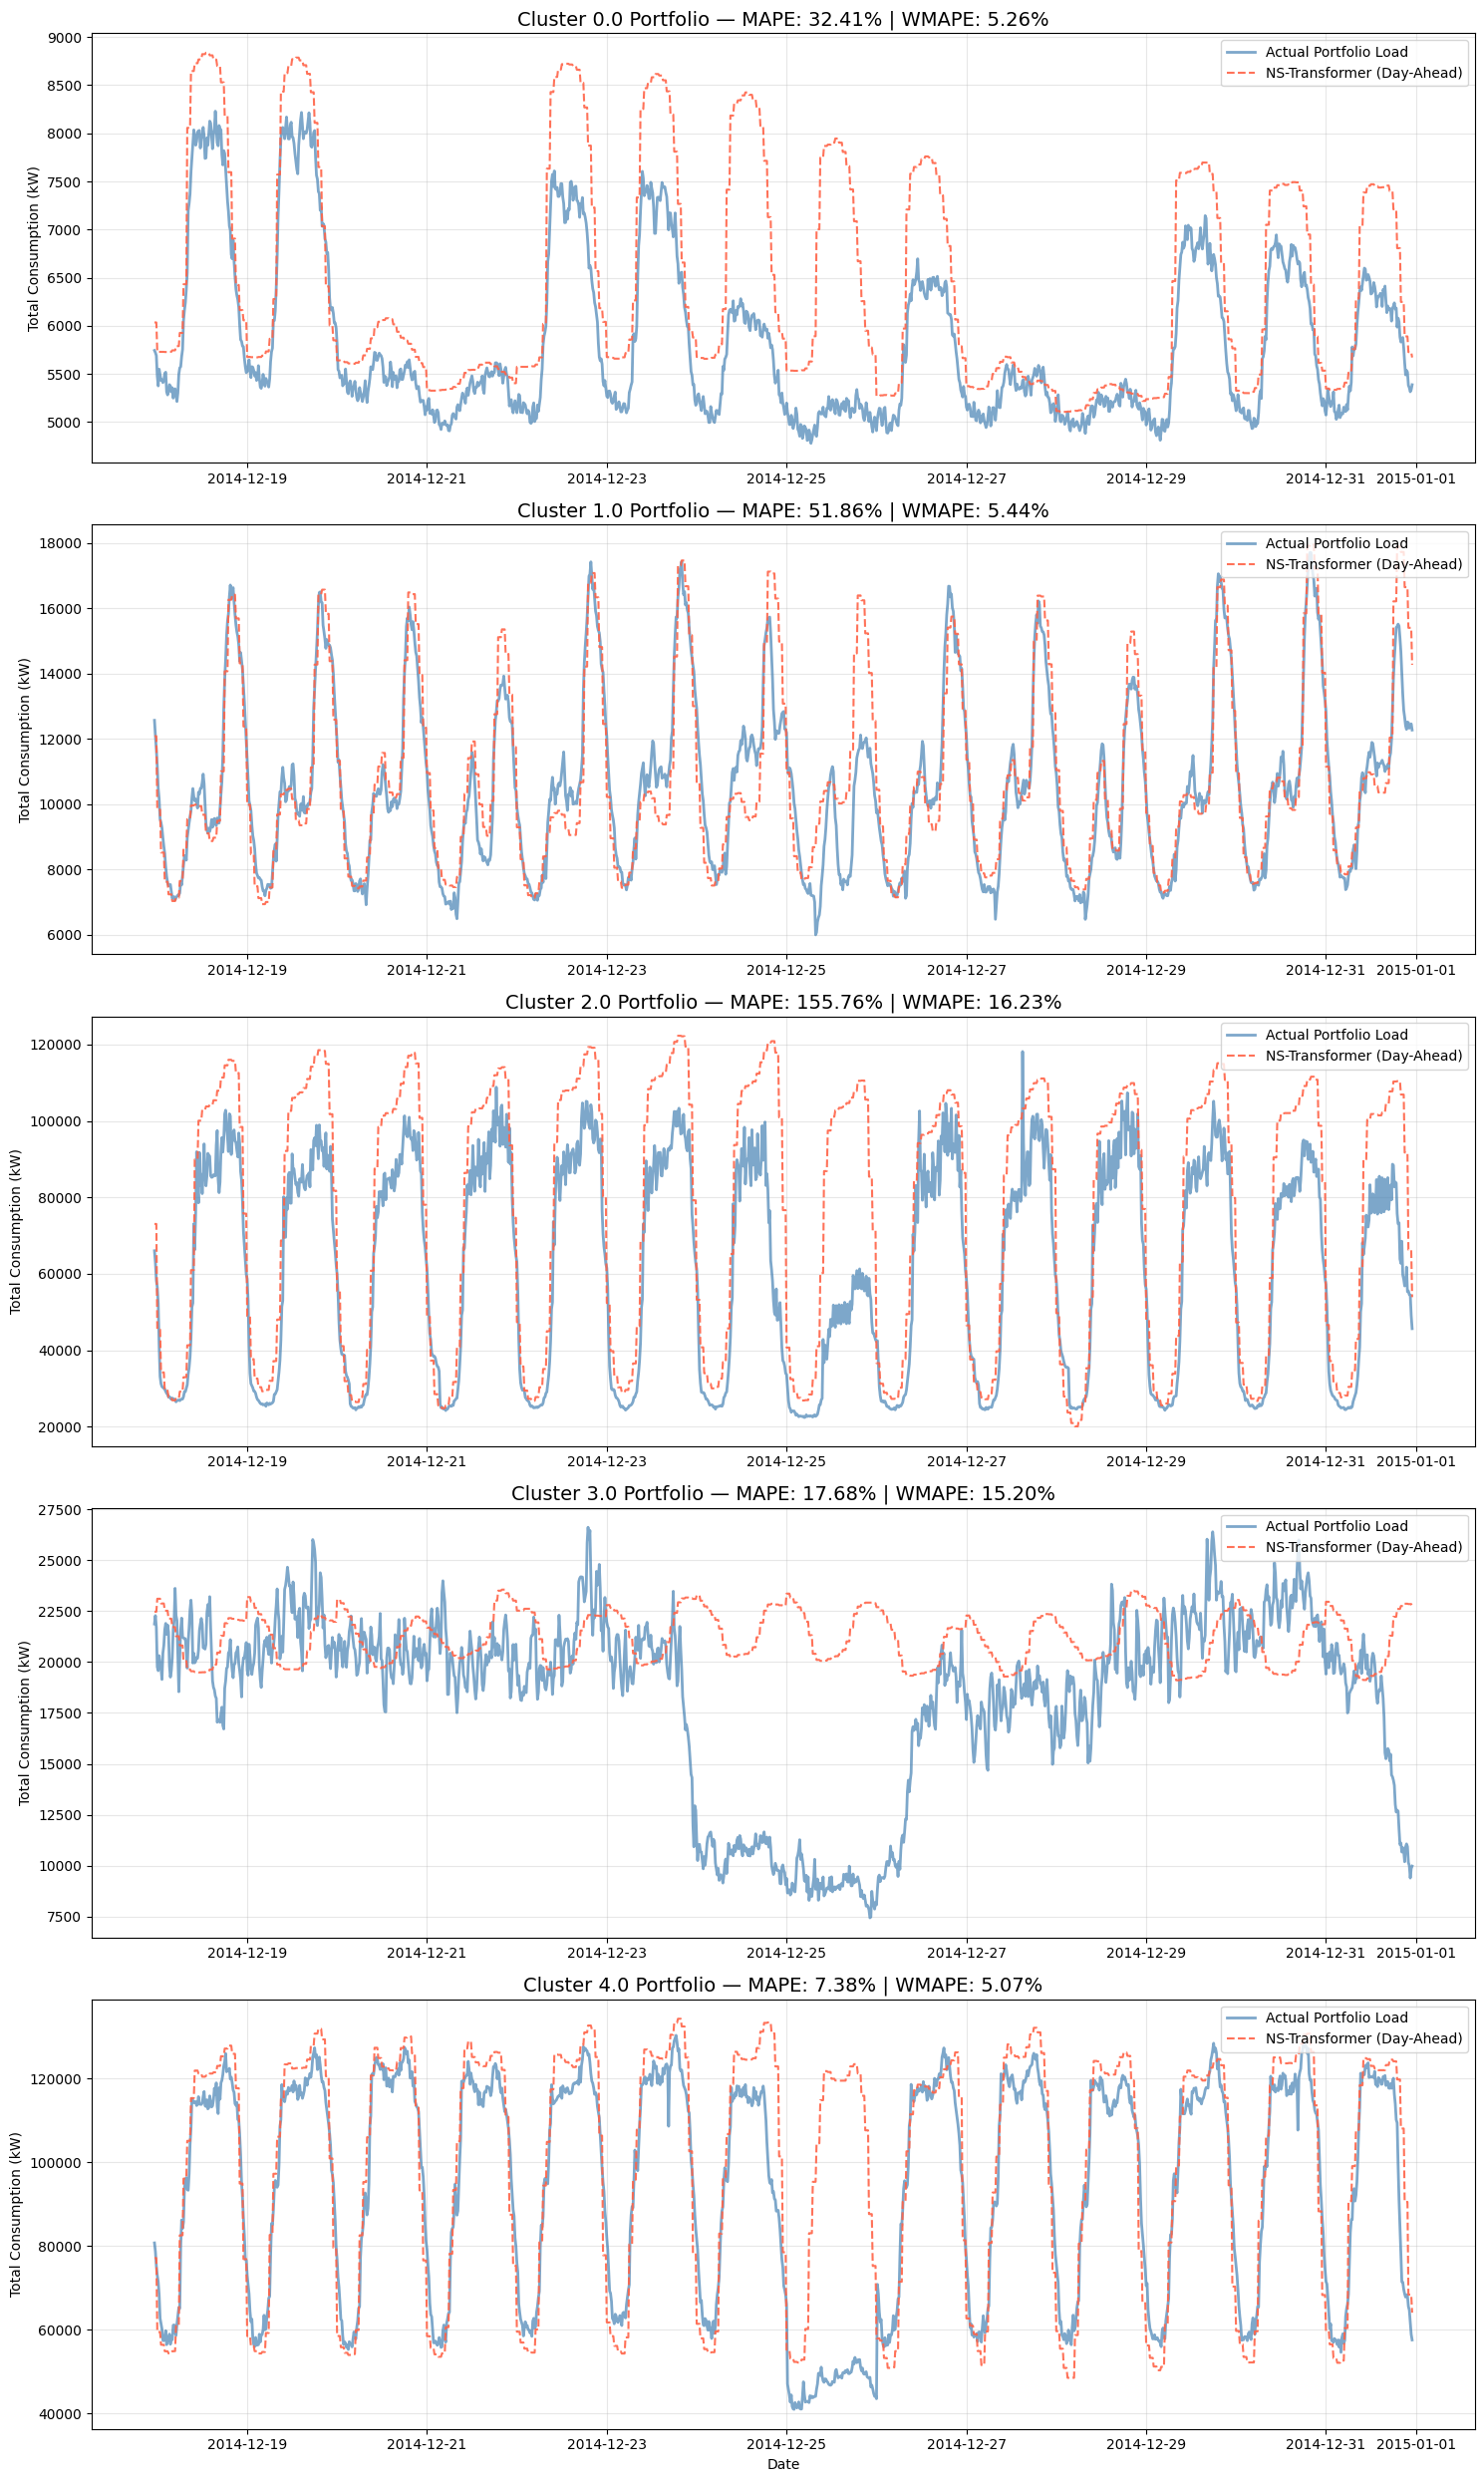


--- PORTFOLIO PERFORMANCE BY TIME PERIOD (Aggregated) ---
  Dec 31 to Apr 02:   WMAPE = 8.17% | MAPE = 20.75%
  Apr 02 to Jul 02:   WMAPE = 5.48% | MAPE = 5.54%
  Jul 02 to Oct 01:   WMAPE = 8.70% | MAPE = 8.34%
  Oct 01 to Dec 31:   WMAPE = 7.56% | MAPE = 8.07%


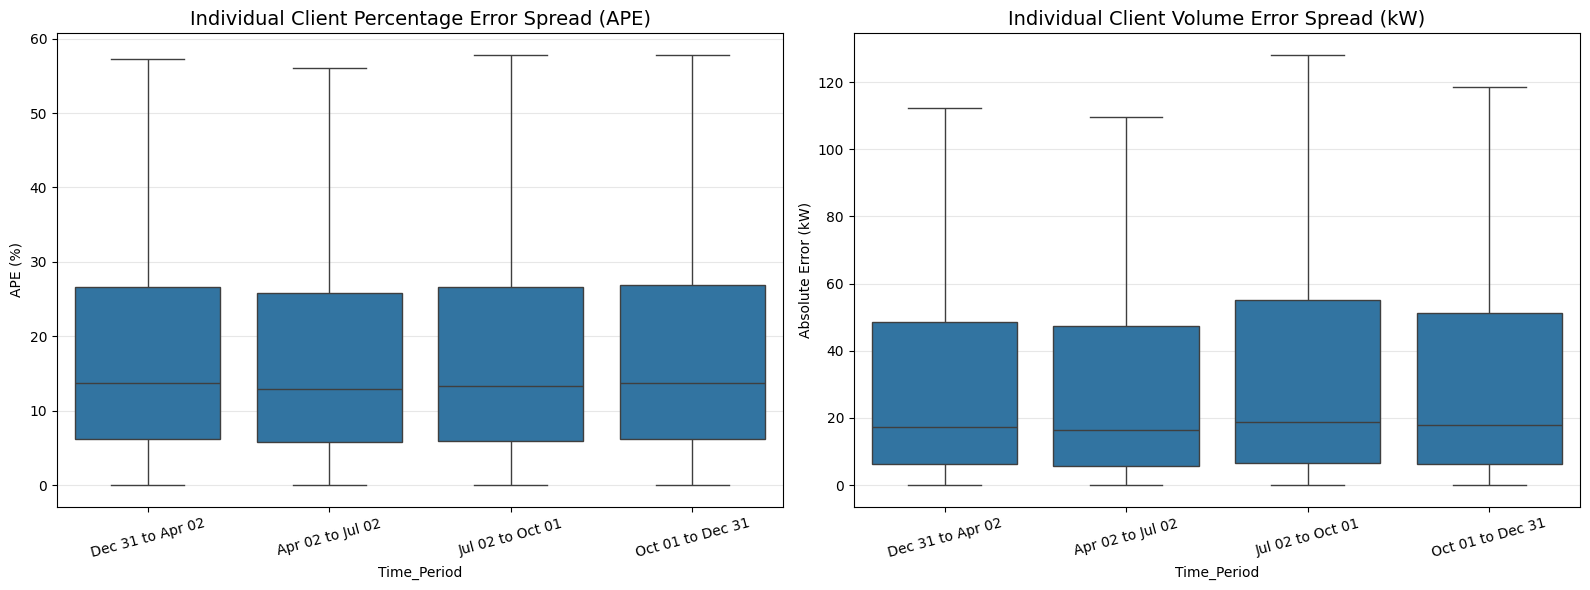

In [8]:
# 6. Save models and plot results
print("Saving artifacts to disk...")
save_transformer_artifacts(
    cluster_models, 
    client_scalers, 
    scaler_weather, 
    regressors, 
    mode=MODE
)

print("Generating plots...")
plot_cluster_portfolio(portfolio_eval, summary, model_label="NS-Transformer")
analyze_time_periods(test_raw)

## 1. Run Modular Pipeline

We run the `day_ahead` scenario. The script will:
- Load the processed Parquet dataset.
- Segment and scale consumption at the client level.
- Train 5 neural models (one per cluster).
- Compute WMAPE/MAPE metrics for the entire portfolio.

In [9]:
DATA_PATH = os.path.join(PROJECT_ROOT, "Datasets", "processed_electricity_data.parquet")

cluster_models, test_raw, portfolio_eval, summary = run_transformer_pipeline(
    DATA_PATH, 
    mode='day_ahead', 
    plot=True
)

Preparing train/test split and scaling (Mode: DAY_AHEAD)...


Scaling Clients: 100%|██████████| 369/369 [00:07<00:00, 46.34it/s]


Aggregating data by Cluster for Transformer training...

Training Cluster 0.0
  Epoch 1 | Train: 0.14750 | Val: 0.13869
  Epoch 2 | Train: 0.03811 | Val: 0.11258
  Epoch 3 | Train: 0.03187 | Val: 0.11986
  Epoch 4 | Train: 0.02811 | Val: 0.11862
  Epoch 5 | Train: 0.02530 | Val: 0.12246

Training Cluster 1.0
  Epoch 1 | Train: 0.22439 | Val: 0.23873
  Epoch 2 | Train: 0.07235 | Val: 0.12863
  Epoch 3 | Train: 0.05166 | Val: 0.10079
  Epoch 4 | Train: 0.04386 | Val: 0.09349
  Epoch 5 | Train: 0.03922 | Val: 0.08856
  Epoch 6 | Train: 0.03616 | Val: 0.08385
  Epoch 7 | Train: 0.03357 | Val: 0.08706


KeyboardInterrupt: 

## 2. Statistical Deep Dive

Beyond the cluster-level portfolio, we analyze the Transformer's performance across different temporal slices (Weekdays vs Weekends, Peak vs Off-Peak hours).

In [ ]:
analyze_time_periods(test_raw)